In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [66]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
url

'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

In [67]:
column_names = ["mpg","cylinders","displacement","horsepower","weight","acceleration","model_year","origin","car_name"]
column_names

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model_year',
 'origin',
 'car_name']

In [68]:
df = pd.read_csv(
    url,
    names=column_names,
    sep=r"\s+", # raw file is separated by whitespace not commas
    na_values="?",  # Treat '?' as NaN
    comment='\t',  # Ignore comments starting with tab
    )
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [69]:
df.shape

(398, 9)

In [70]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger
397,31.0,4,119.0,82.0,2720.0,19.4,82,1,chevy s-10


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [72]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [73]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [74]:
print("Rows before dropping missing values:", df.shape[0])
df = df.dropna().reset_index(drop=True)
print("Rows after dropping missing values:", df.shape[0])

Rows before dropping missing values: 398
Rows after dropping missing values: 392


In [75]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
388,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
389,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
390,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


In [76]:
car_names = df['car_name']

In [77]:
df = df.drop(columns=['car_name'])  # Drop the car_name column as it's not needed for modeling

In [78]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [79]:
df['origin'].unique()

array([1, 3, 2])

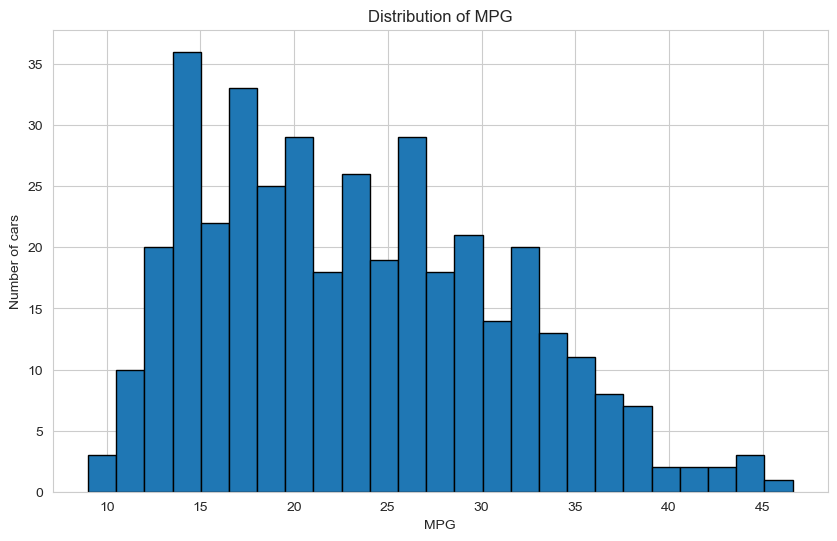

In [80]:
plt.figure()
plt.hist(df['mpg'], bins=25, edgecolor='black')
plt.xlabel('MPG')
plt.ylabel('Number of cars')
plt.title('Distribution of MPG')
plt.show()

In [81]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin'],
      dtype='object')

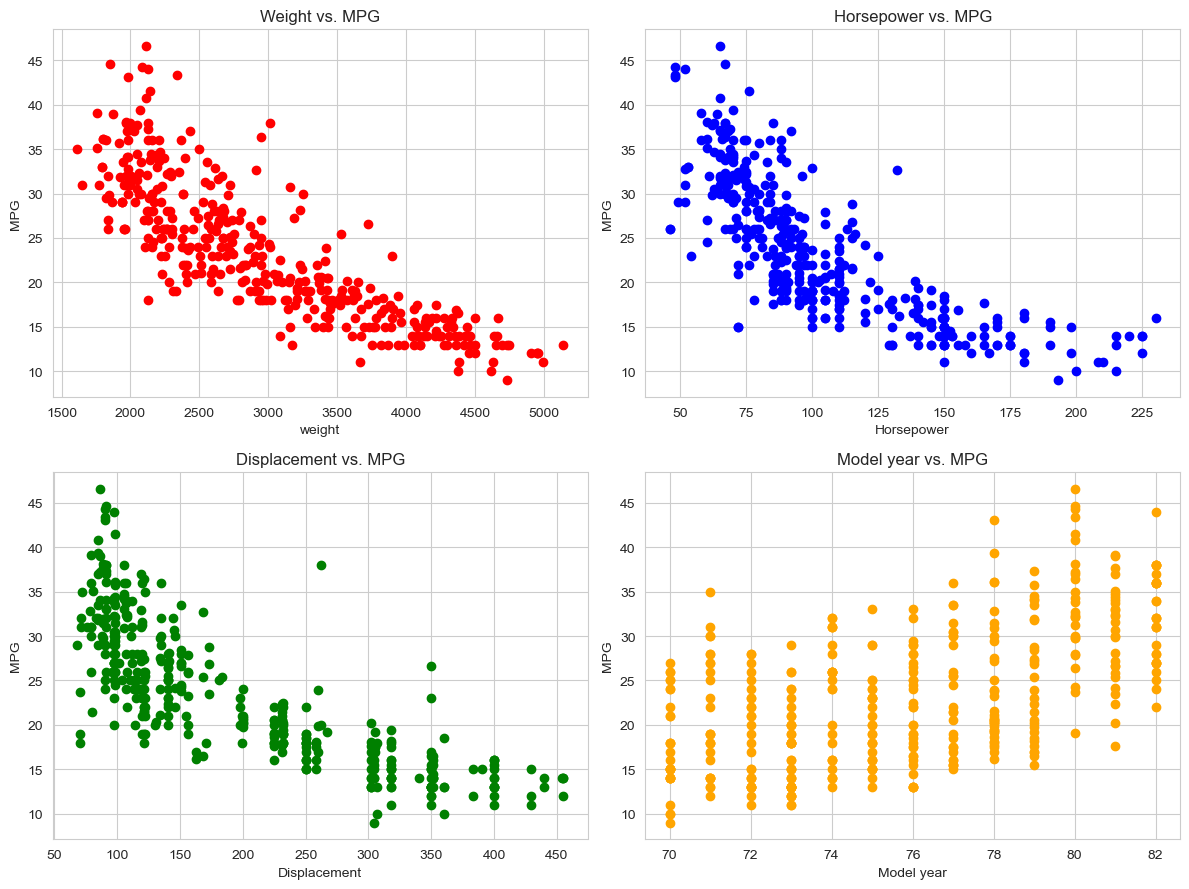

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(df['weight'], df['mpg'], color='red')
axes[0, 0].set_xlabel('weight')
axes[0, 0].set_ylabel('MPG')
axes[0, 0].set_title('Weight vs. MPG')

axes[0, 1].scatter(df['horsepower'], df['mpg'], color='blue')
axes[0, 1].set_xlabel('Horsepower')
axes[0, 1].set_ylabel('MPG')
axes[0, 1].set_title('Horsepower vs. MPG')

axes[1, 0].scatter(df['displacement'], df['mpg'], color='green')
axes[1, 0].set_xlabel('Displacement')
axes[1, 0].set_ylabel('MPG')
axes[1, 0].set_title('Displacement vs. MPG')

axes[1, 1].scatter(df['model_year'], df['mpg'], color='orange')
axes[1, 1].set_xlabel('Model year')
axes[1, 1].set_ylabel('MPG')
axes[1, 1].set_title('Model year vs. MPG')

plt.tight_layout()
plt.show()


C:\Users\Acer\AppData\Local\Temp\ipykernel_3192\1729509651.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['origin'], y=df['mpg'], palette='Set2')


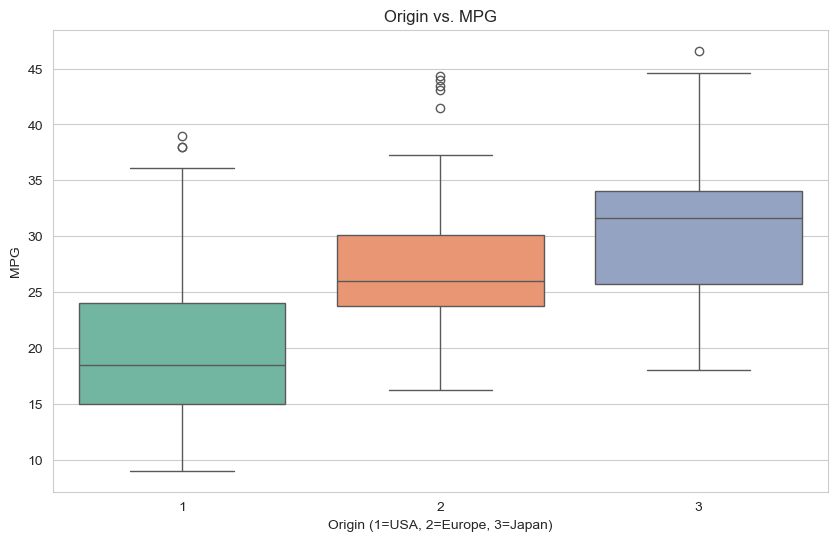

In [83]:
plt.figure()
sns.boxplot(x=df['origin'], y=df['mpg'], palette='Set2')
plt.xlabel('Origin (1=USA, 2=Europe, 3=Japan)')
plt.ylabel('MPG')
plt.title('Origin vs. MPG')
plt.show()

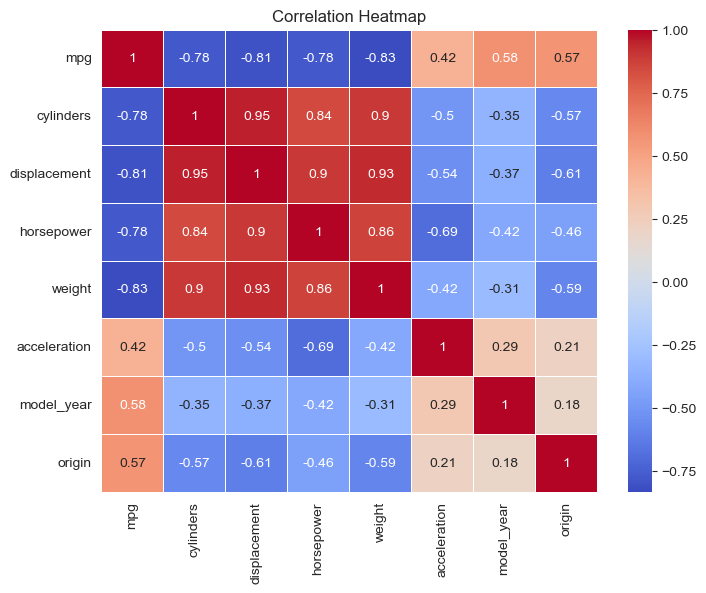

In [84]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [85]:
X = df.drop(columns=['mpg'])
y = df['mpg']

In [86]:
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (392, 7)
y shape: (392,)


In [87]:
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,8,307.0,130.0,3504.0,12.0,70,1
1,8,350.0,165.0,3693.0,11.5,70,1
2,8,318.0,150.0,3436.0,11.0,70,1
3,8,304.0,150.0,3433.0,12.0,70,1
4,8,302.0,140.0,3449.0,10.5,70,1


In [88]:
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [90]:
print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

Training rows: 313
Test rows: 79


In [91]:
X_train['origin']

258    1
182    1
172    1
63     1
340    1
      ..
71     1
106    1
270    1
348    1
102    1
Name: origin, Length: 313, dtype: int64

In [92]:
X_train = pd.get_dummies(X_train, columns=['origin'], prefix='origin')
X_test = pd.get_dummies(X_test, columns=['origin'], prefix='origin')

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [93]:
X_test.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3
78,4.0,96.0,69.0,2189.0,18.0,72.0,0.0,1.0,0.0
274,4.0,121.0,115.0,2795.0,15.7,78.0,0.0,1.0,0.0
246,4.0,91.0,60.0,1800.0,16.4,78.0,0.0,0.0,1.0
55,4.0,91.0,70.0,1955.0,20.5,71.0,1.0,0.0,0.0
387,4.0,140.0,86.0,2790.0,15.6,82.0,1.0,0.0,0.0


In [94]:
X_train.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3
258,6.0,225.0,110.0,3620.0,18.700001,78.0,1.0,0.0,0.0
182,4.0,140.0,92.0,2572.0,14.900000,76.0,1.0,0.0,0.0
172,6.0,171.0,97.0,2984.0,14.500000,75.0,1.0,0.0,0.0
63,8.0,318.0,150.0,4135.0,13.500000,72.0,1.0,0.0,0.0
340,4.0,86.0,64.0,1875.0,16.400000,81.0,1.0,0.0,0.0


In [95]:
normalizer = layers.Normalization(axis=-1)
normalizer.adapt(np.array(X_train))

print('Learned per feature mean (first 5)', normalizer.mean.numpy().flatten()[:5])
print('Learned per feature variance (first 5)', normalizer.variance.numpy().flatten()[:5])

Learned per feature mean (first 5) [   5.482428  195.51758   104.594246 2986.1245     15.544088]
Learned per feature variance (first 5) [2.8822794e+00 1.0733099e+04 1.4609568e+03 7.0524594e+05 7.9149890e+00]


In [96]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [97]:
y_pred_lr = lin_reg.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear regression - MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}, RMSE: {rmse_lr:.2f}, R2: {r2_lr:.2f}")

Linear regression - MAE: 2.46, MSE: 10.60, RMSE: 3.26, R2: 0.79


In [98]:
n_features = X_train.shape[1]

print("Number of input features:", n_features)

Number of input features: 9


In [99]:
dense1_model = keras.Sequential([
    normalizer,
    layers.Dense(1)
])

dense1_model.build(input_shape=(None, n_features))
dense1_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (120.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 19 (80.00 B)

In [100]:
weights, bias = dense1_model.layers[-1].get_weights()
print("Initial weights shape:", weights.shape)
print("Initial weights:", weights.flatten())
print("Inital bias:", bias)


Initial weights shape: (9, 1)
Initial weights: [-0.19661808 -0.01761276  0.22127944  0.12249929  0.5511354  -0.47064844
  0.7430701   0.0876143  -0.03009701]
Inital bias: [0.]


In [101]:
initial_preds = dense1_model.predict(X_train[:5], verbose=0).flatten()
actual_vals = y_train.values[:5]

print("Predicted MPG (untrained model):", np.round(initial_preds, 2))
print("Actual MPG:", actual_vals)

initial_mse = np.mean((initial_preds - actual_vals) ** 2)
print("Initial MSE:", initial_mse)

Predicted MPG (untrained model): [ 0.97  0.48  0.38  0.79 -0.13]
Actual MPG: [18.6 25.  18.  15.  39. ]
Initial MSE: 591.1470454012422


In [102]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [103]:
ann_model = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

ann_model.build(input_shape=(None, n_features))
ann_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,772 (10.83 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 19 (80.00 B)

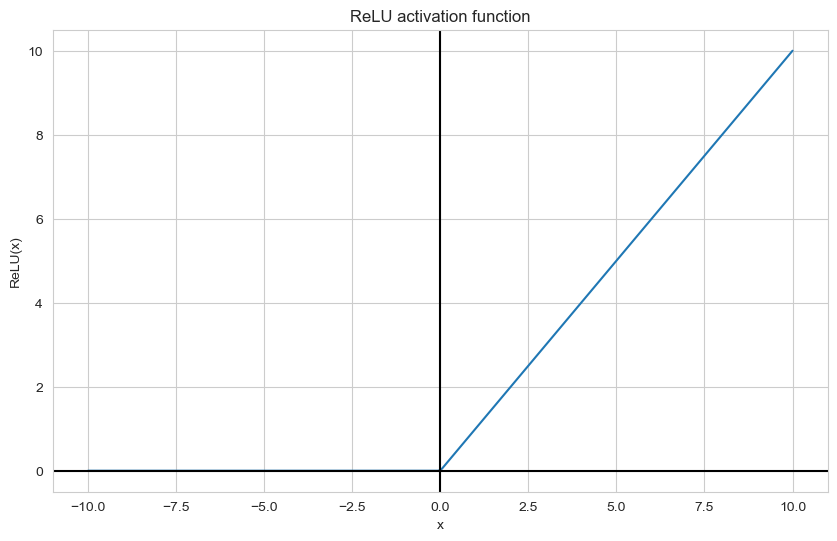

In [104]:
xs = np.linspace(-10, 10, 200)
ys = np.maximum(0, xs)

plt.figure()
plt.plot(xs, ys)
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.title('ReLU activation function')
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.show()

In [105]:
ann_model.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001),
    loss = 'mse',
    metrics = ['mae']
)

In [106]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = ann_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs =200,
    callbacks = [early_stop],
    verbose=0
)

print("Training stopped after", len(history.history['loss']), 'epochs')

Training stopped after 200 epochs


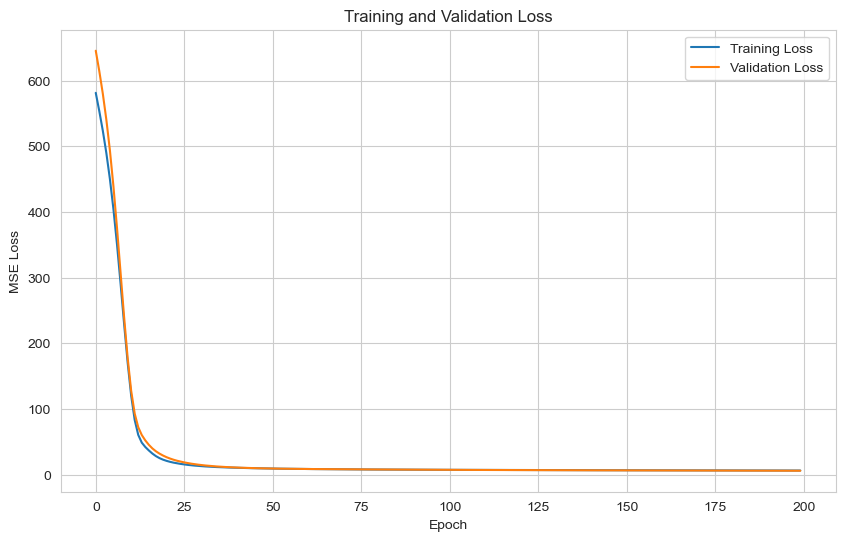

In [107]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [108]:
y_pred_ann = ann_model.predict(X_test, verbose=0).flatten()
mae_ann = mean_absolute_error(y_test, y_pred_ann)
mse_ann = mean_squared_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mse_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print(f"ANN - MAE: {mae_ann:.2f}, MSE: {mse_ann:.2f}, RMSE: {rmse_ann:.2f}, R2: {r2_ann:.2f}")

ANN - MAE: 1.72, MSE: 5.66, RMSE: 2.38, R2: 0.89


In [109]:
dense1_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss = 'mse',
    metrics = ['mae']
)

dense1_history = dense1_model.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs=200,
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
    verbose = 0
)
y_pred_dense1 = dense1_model.predict(X_test, verbose=0).flatten()
mae_dense1 = mean_absolute_error(y_test, y_pred_dense1)
mse_dense1 = mean_squared_error(y_test, y_pred_dense1)
rmse_dense1 = np.sqrt(mse_dense1)
r2_dense1 = r2_score(y_test, y_pred_dense1)

print(f"Dense1 - MAE: {mae_dense1:.2f}, MSE: {mse_dense1:.2f}, RMSE: {rmse_dense1:.2f}, R2: {r2_dense1:.2f}")


Dense1 - MAE: 21.24, MSE: 468.10, RMSE: 21.64, R2: -8.17


In [110]:
mean_pred = np.full_like(y_test, y_train.mean(), dtype='float64')
mae_mean = mean_absolute_error(y_test, mean_pred)
mse_mean = mean_squared_error(y_test, mean_pred)
rmse_mean = np.sqrt(mse_mean)
r2_mean = r2_score(y_test, mean_pred)

print(f"Mean - MAE: {mae_mean:.2f}, MSE: {mse_mean:.2f}, RMSE: {rmse_mean:.2f}, R2: {r2_mean:.2f}")

Mean - MAE: 5.88, MSE: 51.62, RMSE: 7.18, R2: -0.01


In [111]:
comparison = pd.DataFrame({
    'Model': ['Mean predictor (naive baseline)', 'Multiple Linear Regression', 'Tensorflow Dense(1)', 'ANN (64-32-1, ReLU)'],
    'MAE': [mae_mean, mae_lr, mae_dense1, mae_ann],
    'MSE': [mse_mean, mse_lr, mse_dense1, mse_ann],
    'RMSE': [rmse_mean, rmse_lr, rmse_dense1, rmse_ann],
    'R2': [r2_mean, r2_lr, r2_dense1, r2_ann]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,Mean predictor (naive baseline),5.880956,51.620292,7.184726,-0.011358
1,Multiple Linear Regression,2.462000,10.602277,3.256114,0.792278
2,Tensorflow Dense(1),21.237921,468.101730,21.635659,-8.171167
3,"ANN (64-32-1, ReLU)",1.720430,5.658955,2.378856,0.889128


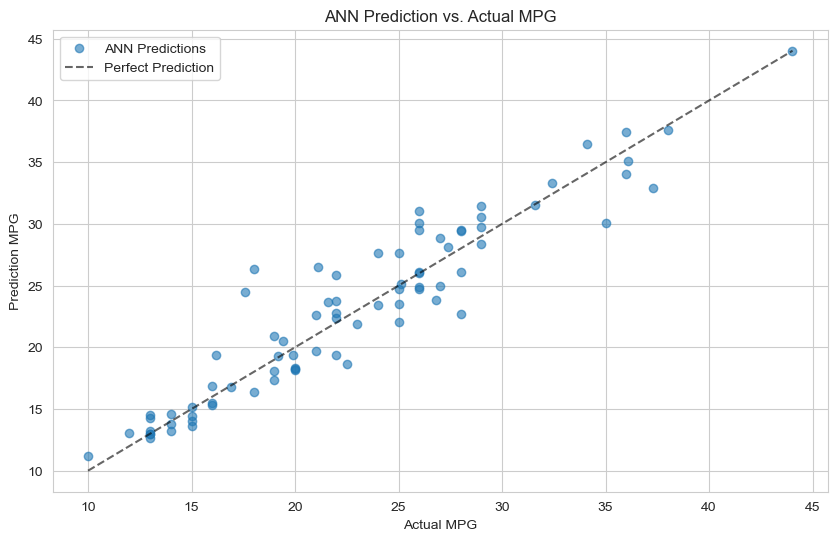

In [112]:
plt.figure()
plt.scatter(y_test, y_pred_ann, alpha=0.6, label='ANN Predictions')
lims = [min(y_test.min(), y_pred_ann.min()), max(y_test.max(), y_pred_ann.max())]
plt.plot(lims, lims, 'k--', alpha=0.6, label='Perfect Prediction')
plt.xlabel('Actual MPG')
plt.ylabel('Prediction MPG')
plt.title('ANN Prediction vs. Actual MPG')
plt.legend()
plt.show()

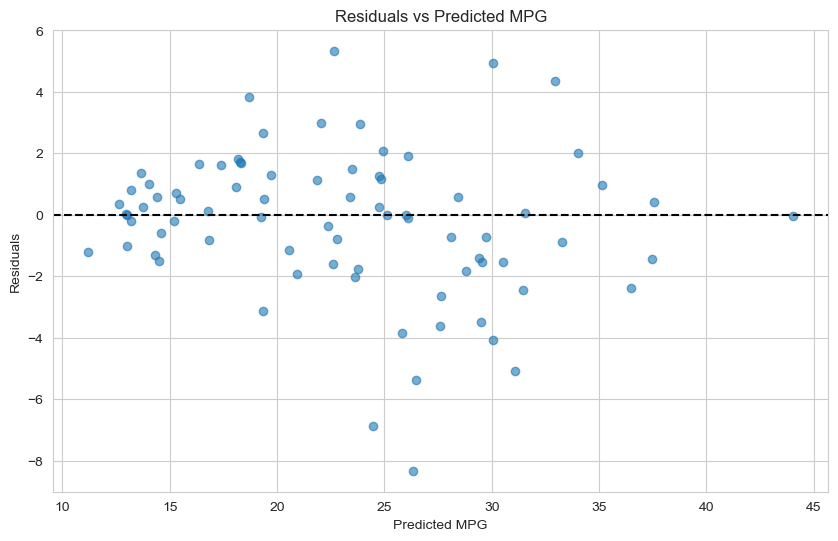

In [113]:
residuals = y_test.values - y_pred_ann

plt.figure()
plt.scatter(y_pred_ann, residuals, alpha=0.6)
plt.axhline(y=0, color = 'black', linestyle='--')
plt.xlabel('Predicted MPG')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted MPG')
plt.show()

In [114]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin'],
      dtype='object')

In [115]:
new_car = pd.DataFrame({
    'cylinders': [4],
    'displacement': [140.0],
    'horsepower': [100.0],
    'weight': [2500.0],
    'acceleration': [15.0],
    'model_year': [70],
    'origin': [1]
})

In [116]:
new_car_encoded = pd.get_dummies(new_car, columns=['origin'], prefix='origin')
new_car_encoded = new_car_encoded.reindex(columns=X_train.columns, fill_value=0).astype('float32')

predicted_mpg = ann_model.predict(new_car_encoded, verbose=0).flatten()[0]
print('Input features:')
print(new_car)
print(f"\nPredicted MPG: {predicted_mpg:.2f}")

Input features:
   cylinders  displacement  horsepower  weight  acceleration  model_year  \
0          4         140.0       100.0  2500.0          15.0          70   

   origin  
0       1  

Predicted MPG: 21.32


In [117]:
coef_table = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient':lin_reg.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coef_table

,Feature,Coefficient
6,origin_1,-2.027155
8,origin_3,1.178813
7,origin_2,0.848343
5,model_year,0.797161
0,cylinders,-0.342099
4,acceleration,0.042199
2,horsepower,-0.021620
1,displacement,0.019206
3,weight,-0.006423


In [118]:
!pip install kerasWrapper

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement kerasWrapper (from versions: none)
ERROR: No matching distribution found for kerasWrapper


In [120]:
def ann_predict_fn(X_input):
  return ann_model.predict(X_input, verbose=0).flatten()

from sklearn.base import BaseEstimator, RegressorMixin

class KerasWrapper(BaseEstimator, RegressorMixin):
  def __init__(self, keras_model):
    self.keras_model = keras_model

  def fit(self, X, y=None):
    return self

  def predict(self, X):
    return self.keras_model.predict(np.asarray(X), verbose=0).flatten()

wrapped_ann = KerasWrapper(ann_model)

perm_result = permutation_importance(
    wrapped_ann,
    np.asarray(X_test),
    y_test.values,
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

perm_table = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance (MSE increase when shuffled)' : perm_result.importances_mean
}).sort_values('Importance (MSE increase when shuffled)', ascending=False)

perm_table

,Feature,Importance (MSE increase when shuffled)
5,model_year,17.779520
3,weight,15.685310
6,origin_1,11.333115
2,horsepower,10.138110
7,origin_2,8.926587
1,displacement,6.998573
8,origin_3,5.461920
4,acceleration,2.058559
0,cylinders,1.337051


In [121]:
def build_and_train_ann(X_tr, X_te, y_tr, y_te, name):
    norm = layers.Normalization(axis=-1)
    norm.adapt(np.array(X_tr))

    model = keras.Sequential([
        norm,
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
    ])

    model.compile(optimizer= keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    hist = model.fit(X_tr, y_tr, validation_split=0.2, epochs=200, callbacks=[es], verbose=0)

    preds = model.predict(X_te, verbose=0).flatten()
    mae = mean_absolute_error(y_te, preds)
    mse = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_te, preds)
    print(f"{name} - MAE: {mse:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

    return model, hist, {'MAE': mae, 'MSE':mse, 'RMSE':rmse, 'R2':r2}

feture_sets = {
    'Model A : all features': list(X_train.columns),
    'Model B : weight + horsepower only': ['weight', 'horsepower'],
    'Model C : weight + displacement only': ['weight','displacement'],
}

feature_results = {}
for name, cols in feture_sets.items():
    m, h, res = build_and_train_ann(X_train[cols], X_test[cols], y_train, y_test, name)
    feature_results[name] = res

Model A : all features - MAE: 5.60, MSE: 5.60, RMSE: 2.37, R2: 0.89
Model B : weight + horsepower only - MAE: 15.89, MSE: 15.89, RMSE: 3.99, R2: 0.69
Model C : weight + displacement only - MAE: 18.06, MSE: 18.06, RMSE: 4.25, R2: 0.65


In [124]:
architectures = {
    'Model 1 : Dense(1) only' : [],
    'Model 2 : Dense(16, relu) -> Dense(1)' : [16],
    'Model 3 : Dense(64, relu) -> Dense(32, relu) -> Dense(1)' : [64, 32]
}

arch_results = {}

for name, hidden_units in architectures.items():
  norm = layers.Normalization(axis=-1)
  norm.adapt(np.array(X_train))

  layer_list = [norm]
  for units in hidden_units:
    layer_list.append(layers.Dense(units, activation='relu'))
  layer_list.append(layers.Dense(1))

  model = keras.Sequential(layer_list)
  model.compile(optimizer = keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])

  es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
  hist = model.fit(X_train, y_train, validation_split=0.2, epochs=200, callbacks=[es], verbose=0)

  preds = model.predict(X_test, verbose=0).flatten()
  mae = mean_absolute_error(y_test, preds)
  mse = mean_squared_error(y_test, preds)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, preds)
  n_params = model.count_params()
  arch_results[name] = {'Params' : n_params, 'MAE':mae, 'MSE':mse, 'RMSE':rmse, 'R2':r2, 'Epochs': len(hist.history['loss'])}
  print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}, Epochs: {len(hist.history['loss'])}, Params: {n_params}")

pd.DataFrame(arch_results).T


Model 1 : Dense(1) only - MAE: 21.16, MSE: 461.44, RMSE: 21.48, R2: -8.04, Epochs: 200, Params: 29
Model 2 : Dense(16, relu) -> Dense(1) - MAE: 2.54, MSE: 11.08, RMSE: 3.33, R2: 0.78, Epochs: 200, Params: 196
Model 3 : Dense(64, relu) -> Dense(32, relu) -> Dense(1) - MAE: 1.75, MSE: 5.80, RMSE: 2.41, R2: 0.89, Epochs: 200, Params: 2772


,Params,MAE,MSE,RMSE,R2,Epochs
Model 1 : Dense(1) only,29.0,21.160373,461.435919,21.481060,-8.040569,200.0
"Model 2 : Dense(16, relu) -> Dense(1)",196.0,2.538594,11.081584,3.328901,0.782887,200.0
"Model 3 : Dense(64, relu) -> Dense(32, relu) -> Dense(1)",2772.0,1.751510,5.804677,2.409290,0.886273,200.0


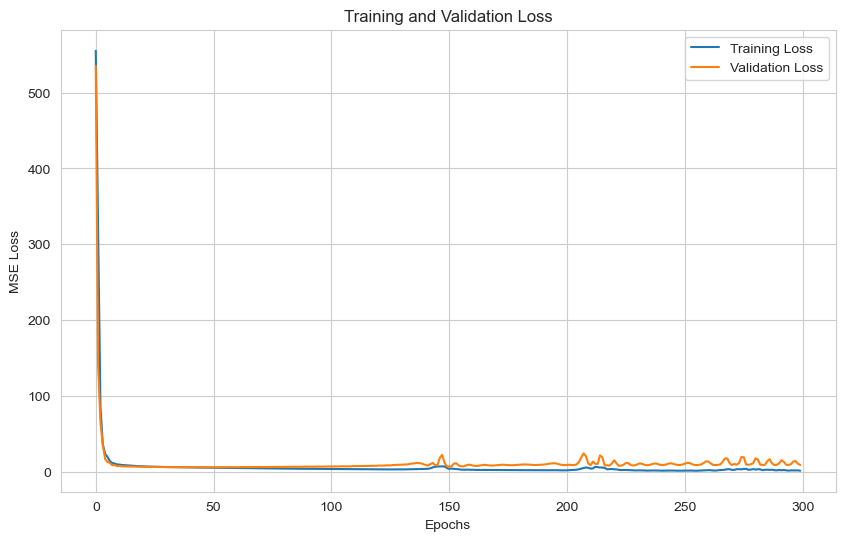

In [126]:
big_norm = layers. Normalization(axis=-1)
big_norm.adapt(np.array(X_train))

big_model = keras.Sequential([
    big_norm,
layers.Dense(256, activation='relu'),
layers.Dense(256, activation='relu'),
layers.Dense(128, activation='relu'),
layers.Dense(64, activation='relu'),
layers.Dense(1)
])

big_model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])

big_history = big_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=300,
    verbose=0
)

plt.figure()
plt.plot(big_history.history['loss'], label='Training Loss')
plt.plot(big_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [128]:
big_norm2 = layers.Normalization(axis=-1)
big_norm2.adapt(np.array(X_train))

big_model_es = keras. Sequential([
    big_norm2,
layers.Dense(256, activation='relu'),
layers.Dense(256, activation='relu'),
layers.Dense(128, activation='relu'),
layers.Dense(64, activation='relu'),
layers.Dense(1)
])

big_model_es.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])

es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
big_history_es = big_model_es.fit(
    X_train, y_train,
    validation_split =0.2,
    epochs=300,
    callbacks = [es],
    verbose = 0
)

print("Training stopped after", len(big_history_es.history['loss']), 'epochs (vs 300 without early stopping)')

preds_big = big_model.predict(X_test, verbose=0).flatten()
preds_big_es = big_model_es.predict(X_test, verbose=0).flatten()

print(f"Oversized network, no early stopping -> RMSE: {np.sqrt(mean_squared_error(y_test, preds_big))} | R2 : {r2_score(y_test, preds_big)}")
print(f"Oversized network, with early stopping -> RMSE: {np.sqrt(mean_squared_error(y_test, preds_big_es))} | R2 : {r2_score(y_test, preds_big_es)}")


Training stopped after 80 epochs (vs 300 without early stopping)
Oversized network, no early stopping -> RMSE: 3.4272127956297846 | R2 : 0.7698735633303962
Oversized network, with early stopping -> RMSE: 2.5377352303573772 | R2 : 0.8738239320438065
